In [69]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from utils.colors import CMAP
from fenics import Function, plot
from utils.exact_forward_operator import ExactForwardOperator
from utils.problem_setup import TestProblemsSetup
from utils.plotting import save_plot

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [16]:
pid = 'I'
setup = TestProblemsSetup(n=64)
problems = setup.get_test_problems()
p = problems[pid]

exact = ExactForwardOperator(p['V_h'])
S = exact.assemble_S()
K = exact.K

In [17]:
f = p['f']
u = Function(p['V_h'])

x = p['x']
u.vector()[:] = S @ x

f_list = [f, u, u]

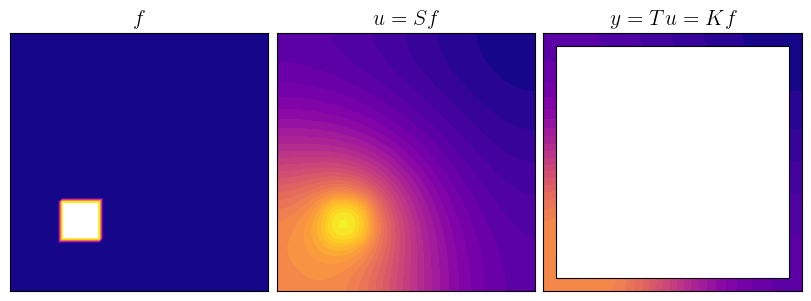

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(8, 6), constrained_layout=True)
axes = axes.flatten()

names = ["$f$", "$u = Sf$", "$y = Tu = Kf$"]

for i, (ax, f, name) in enumerate(zip(axes, f_list, names)):
    plt.sca(ax)

    p0 = plot(f, title=name, cmap=CMAP)
    ax.set_xticks([])
    ax.set_yticks([])

# Add path to right plot
ax = axes[2]
plt.sca(ax)
rect = patches.Rectangle(
    (0.05, 0.05), 0.9, 0.9, # (x0, y0), width, height
    linewidth=0.8,
    edgecolor="black",
    facecolor="white",
    zorder=10
)
ax.add_patch(rect)
plt.show()


In [ ]:
def tikhonov(K, M, M_partial, y, lam):
    """Tikhonov regularization for a linear system Ax = b."""
    LHS = K.T @ M_partial @ K + (lam ** 2) * M
    RHS = K.T @ y
    return np.linalg.solve(LHS, RHS)

# Solve 
y = K @ x
x_hat  = tikhonov(K, exact.M_dx, exact.M_ds, y, lam=1e-4)
f_hat = Function(p['V_h'])
f_hat.vector()[:] = np.maximum(x_hat, -0.3)  # some outlier points (fix color-scale, shape is unchanged)

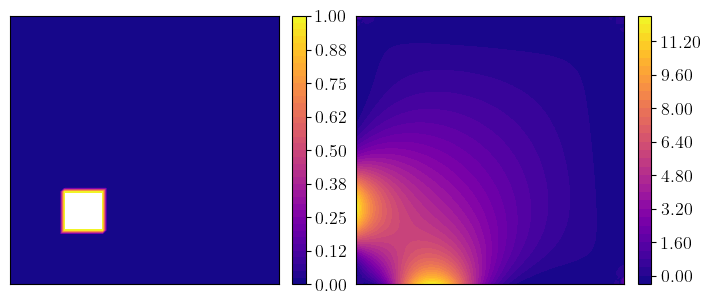

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(7, 4), constrained_layout=True)
axes = axes.flatten()

funcs = [p['f'], f_hat]
names = ["True solution $f$", "Tikhonov solution $f_\lambda$"]
for ax, func, name in zip(axes, funcs, names):
    plt.sca(ax)
    p0 = plot(func, cmap=CMAP)
    fig.colorbar(p0, ax=ax, format="%.2f", shrink=0.685)
    ax.set_xticks([])
    ax.set_yticks([])
    
save_plot("standard_tikhonov_solution")
plt.show()